In [1]:
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

In [2]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [3]:
pip install kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
kaggle_credentails = json.load(open("./kaggle.json"))

In [9]:
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [ ]:
! kaggle datasets download -d abdallahalidev/plantvillage-dataset
# ! kaggle datasets download -d rashikrahmanpritom/plant-disease-recognition-dataset

^C


In [31]:
ls

 Volume in drive D is New Volume
 Volume Serial Number is 1028-6068

 Directory of d:\DEV Notes\ALL_SDGProject_Related WOrk\SCA-Project\model

16-03-2025  17:52    <DIR>          .
28-02-2025  20:47    <DIR>          ..
28-02-2025  22:12               593 app.py
10-03-2025  21:20             1,316 class_indices.json
16-03-2025  17:49           343,627 diesease_model.ipynb
06-03-2025  19:10                67 kaggle.json
28-10-2019  12:25     2,189,386,419 plantvillage-dataset.zip
28-02-2025  22:02             2,082 requirements.txt
28-02-2025  21:59    <DIR>          venv
               6 File(s)  2,189,734,104 bytes
               3 Dir(s)  49,983,471,616 bytes free


In [10]:
with ZipFile("plant-disease-recognition-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

BadZipFile: File is not a zip file

In [33]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'grayscale', 'segmented']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [34]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_HL 6067.JPG', '0163a6aa-fbf8-47c5-965f-59b6efe8bfe5___Mt.N.V_HL 6103.JPG', '0294ca65-4c29-44be-af28-501df9f715e8___Mt.N.V_HL 6176.JPG', '02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_HL 9078.JPG', '03027791-26bb-4c46-960e-8df76e27042c___Mt.N.V_HL 6070.JPG']


Data PreProcessing

In [35]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

[[[125 119 121]
  [127 121 123]
  [128 122 124]
  ...
  [195 191 192]
  [194 190 191]
  [193 189 190]]

 [[120 114 116]
  [122 116 118]
  [125 119 121]
  ...
  [188 184 185]
  [188 184 185]
  [187 183 184]]

 [[124 118 120]
  [123 117 119]
  [122 116 118]
  ...
  [190 186 187]
  [190 186 187]
  [189 185 186]]

 ...

 [[190 180 178]
  [192 182 180]
  [191 181 179]
  ...
  [159 154 148]
  [159 154 148]
  [159 154 148]]

 [[191 181 179]
  [190 180 178]
  [188 178 176]
  ...
  [160 155 149]
  [161 156 150]
  [162 157 151]]

 [[179 169 167]
  [178 168 166]
  [181 171 169]
  ...
  [162 157 151]
  [164 159 153]
  [165 160 154]]]
(256, 256, 3)


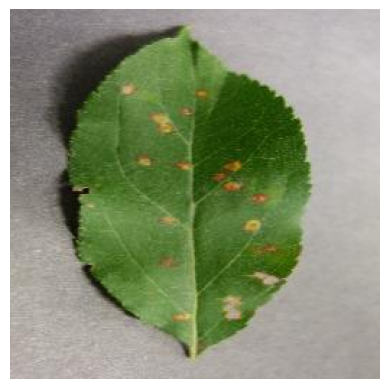

In [36]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Recommended approach using os.path.join()
base_dir = r"D:\DEV Notes\ALL_SDGProject_Related WOrk\SCA-Project\model\plantvillage dataset\color"
image_path = os.path.join(base_dir, "Apple___Cedar_apple_rust", "0cd24b0c-0a9d-483f-8734-5c08988e029f___FREC_C.Rust 3762.JPG")

# Check if file exists
if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    print(img)
    print(img.shape)

    # Display the image
    plt.imshow(img)
    plt.axis('off')
    plt.show()
else:
    print(f"❌ File not found at: {image_path}")


In [37]:
# Image Parameters
img_size = 224
batch_size = 32

In [38]:
# Image Data Generators
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Use 20% of data for validation
)

In [39]:
# Train Generator
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [40]:
# Validation Generator
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


In [41]:
# Model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))


model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

In [42]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [44]:
# Training the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,  # Number of steps per epoch
    epochs=5,  # Number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size  # Validation steps
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1291s 947ms/step - accuracy: 0.6043 - loss: 1.8645 - val_accuracy: 0.8314 - val_loss: 0.5335
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 56us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 1.3414
Epoch 3/5


c:\Users\Prashant\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 1015s 747ms/step - accuracy: 0.9178 - loss: 0.2603 - val_accuracy: 0.8756 - val_loss: 0.4187
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 21us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 1.9073e-06
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 886s 652ms/step - accuracy: 0.9683 - loss: 0.0993 - val_accuracy: 0.8797 - val_loss: 0.4573


In [45]:
# Model Evaluation
print("Evaluating model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - accuracy: 0.8828 - loss: 0.4506
Validation Accuracy: 87.97%


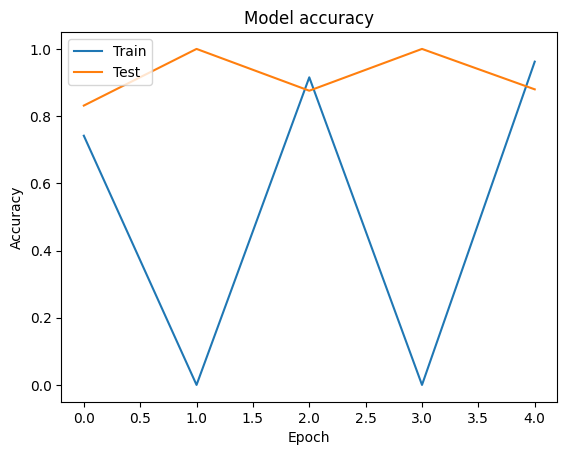

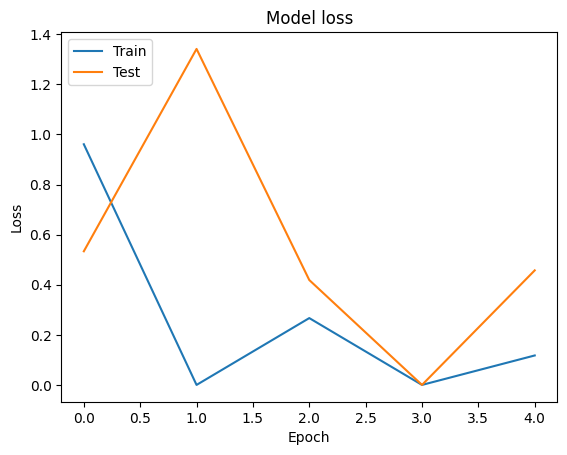

In [46]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [47]:
# Function to Load and Preprocess the Image using Pillow
def load_and_preprocess_image(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image
def predict_image_class(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [48]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [49]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [50]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [51]:
# Example Usage
base_dir = r"D:\DEV Notes\ALL_SDGProject_Related WOrk\SCA-Project\model\plantvillage dataset\color"
image_path = os.path.join(base_dir, "Strawberry___Leaf_scorch", "0c3c9e71-d339-4201-a32a-7a28f0556258___RS_L.Scorch 0930.JPG")
#image_path = '/content/test_blueberry_healthy.jpg'
#image_path = '/content/test_potato_early_blight.jpg'
predicted_class_name = predict_image_class(model, image_path, class_indices)

# Output the result
print("Predicted Class Name:", predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Class Name: Strawberry___Leaf_scorch


In [52]:
import os

# Create the folder if it doesn't exist
save_dir = os.path.join("saved_models")
os.makedirs(save_dir, exist_ok=True)

# Save model
model.save(os.path.join(save_dir, 'plant_disease_prediction_model.h5'))
